# [LAB-10] 3. 다중로지스틱회귀 - 연습문제

## 준비작업

### 라이브러리 참조

In [ ]:
# 순서 정리 (LAB-10 다중로지스틱회귀 연습문제 - nursing_grades)

# 1. 준비작업
# 라이브러리 참조 (jussam.load_data, helpers, pandas.DataFrame)
# 데이터 불러오기 (load_data('nursing_grades'))

# 2. 데이터 품질검사
# 결측치 확인 (my_qtcheck.check_missing_values)
# 자료형 점검 (my_qtcheck.set_type) — 성별, 합격여부를 category로 지정
# 중복검사 (check_duplicates)
# 기초 통계량 확인 (numerical_summary)
# 범주형 변수 확인 (categorical_summary) → 합격여부가 불합격/합격/보류 3종임을 확인

# 3. 분석 대상 정리 (종속변수 전제 맞추기)
# 이항 로지스틱은 종속변수가 두 값이어야 함 → '보류' 23건 제거 (df3)
# 설명력 없는 식별자 컬럼(접수코드, 이름) 제거
# → 400 - 23 = 377행이 최종 분석 대상

# 4. 범주형 변수 라벨링
# my_prep.labeling(df3, columns=['성별','합격여부']) → 0/1 인코딩

# 5. 다중공선성 점검
# 제거 전 VIF 확인 (my_stats.compute_vif)
# VIF 가장 큰 변수부터 반복 제거 (my_prep.reduce_vif)

# 6. 후진소거법 적용 다중 로지스틱 회귀
# my_logit.auto_logit(df5, y='합격여부', backward=True)
# 기준선(4변수): 병원경력 0.000 < 학부성적 0.011 < 필기점수 0.060 < 성별 0.477
#   → 성별 제거(1순위, p=0.477)
# 성별 제거 후 재적합: 필기점수 p값 0.060→0.066으로 재상승
#   → 필기점수 제거(2순위, p=0.066)
#   ※ 기준선 p값과 소거 시점 p값이 다르다는 것 자체가 "한번에 하나씩만 제거"해야 하는 근거
# 최종: 학부성적, 병원경력 2개 변수만 남음

# 7. 결과 보고
# 모형 적합도: n=377, LLR χ²(2)=35.164, p<0.001, Pseudo R²=0.073 (설명력은 낮음, %로 해석 금지)
# 오즈비(OR): 학부성적 1점↑ → 오즈 2.902배 (exp(B)=exp(1.065))
#   ※ "확률이 2.9배"가 아니라 "오즈가 2.9배"임에 주의
# 표준화계수(βstd)로 영향력 비교: 병원경력 |-0.536| > 학부성적 |0.411|
#   → 오즈비만 보면 학부성적이 더 커 보이지만 값의 범위(표준편차)가 달라 직접비교 불가
#   → 표준화한 βstd로 비교해야 병원경력이 실제 1위

# 8. 새 지원자 예측
# my_logit.predict(fit, new_data) — 모형에 남은 변수(학부성적, 병원경력)만 넣어 예측
# 학점3.8/경력1년 → 확률 0.629(합격) vs 경력4년 → 0.234(불합격)
# → 경력 변화폭이 학점 변화폭보다 확률에 더 크게 작용 (βstd 결론과 일치)

In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## 📚 입학처 조교의 합격 요인 규명

### 당신은 한울간호대학교 대학원 입학처에 배치된 신입 조교입니다.

지난 전형에 지원한 400명의 원서 자료(성별, 필기점수, 학부성적, 병원경력)와 최종 결과가 nursing_grades 데이터 셋에 담겨 있습니다.

입학처장은 "내년 모집요강을 손보려는데, 실제로 합격을 가른 요소가 무엇인지 딱 하나만 짚어 달라"고 요구합니다. 그런데 원서 자료를 열어 보니 결과가 아직 확정되지 않은 지원자가 섞여 있어서, 합격/불합격 두 값을 전제하는 모형에 이대로 넣을 수 없습니다.

합격 여부가 보류로 분류 되어 있는 데이터를 제거하고 설명력이 없는 항목을 걷어낸 뒤, 합격 확률을 좌우하는 요인이 무엇인지 로지스틱 회귀로 확인하세요.

### 💻 코드 작성

#### 데이터 불러오기

In [2]:
origin = load_data('nursing_grades')
origin.head()

📚 어느 간호학과 대학원에 지원한 학생들에 대한 합격/불합격 여부를 조사한 가상의 데이터(메타데이터 없음)


,접수코드,이름,성별,필기점수,학부성적,병원경력,합격여부
0,NRS0001,장은우,남,380,3.610,3,불합격
1,NRS0002,최지호,남,660,3.670,3,합격
2,NRS0003,김하준,남,800,4.000,1,합격
3,NRS0004,임아윤,여,640,3.190,4,합격
4,NRS0005,강하준,남,520,2.930,4,불합격


#### 결측치 확인

In [3]:
my_qtcheck.check_missing_values(origin)

,Missing Count,Missing Ratio (%)
접수코드,0,0.000
이름,0,0.000
성별,0,0.000
필기점수,0,0.000
학부성적,0,0.000
병원경력,0,0.000
합격여부,0,0.000


#### 자료형 점검 및 중복 데이터 제거

In [4]:
df1 = my_qtcheck.set_type(origin, as_category=['성별', '합격여부'])

df2 = my_qtcheck.check_duplicates(df1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   접수코드    400 non-null    object  
 1   이름      400 non-null    object  
 2   성별      400 non-null    category
 3   필기점수    400 non-null    int64   
 4   학부성적    400 non-null    float64 
 5   병원경력    400 non-null    int64   
 6   합격여부    400 non-null    category
dtypes: category(2), float64(1), int64(2), object(2)
memory usage: 16.8+ KB
중복된 행의 수: 0


#### 기초 통계량 확인

In [5]:
my_qtcheck.numerical_summary(df2).T

,필기점수,학부성적,병원경력
count,400.000,400.000,400.000
mean,587.700,3.390,2.485
std,115.517,0.381,0.944
min,220.000,2.260,1.000
25%,520.000,3.130,2.000
50%,580.000,3.395,2.000
75%,660.000,3.670,3.000
max,800.000,4.000,4.000
rel_diff,0.013,0.002,0.242
rdiff_flag,similar,similar,diff


#### 범주형 변수 확인

In [6]:
my_qtcheck.categorical_summary(df2, columns=['성별', '합격여부'])

📊 컬럼 '성별'의 value_counts():


,count
성별,
남,194
여,206


📊 컬럼 '합격여부'의 value_counts():


,count
합격여부,
보류,23
불합격,250
합격,127


,성별,합격여부
count,400,400
unique,2,3
top,여,불합격
freq,206,250


#### 분석 대상 정리

In [7]:
# 결과가 확정되지 않은 지원자 제외 + 설명력이 없는 식별자 컬럼 제거
df3 = df2[df2['합격여부'] != '보류'].reset_index(drop=True)
df3 = df3.drop(columns=['접수코드', '이름'])

print(f"분석 대상 관측치 개수: {len(df3)}")

df3.head()

분석 대상 관측치 개수: 377


,성별,필기점수,학부성적,병원경력,합격여부
0,남,380,3.610,3,불합격
1,남,660,3.670,3,합격
2,남,800,4.000,1,합격
3,여,640,3.190,4,합격
4,남,520,2.930,4,불합격


#### 범주형 변수 라벨링

In [8]:
df4 = my_prep.labeling(df3, columns=['성별', '합격여부'])
df4.head()

성별 (2종): 남=0, 여=1
합격여부 (2종): 불합격=0, 합격=1


,성별,필기점수,학부성적,병원경력,합격여부
0,0,380,3.610,3,0
1,0,660,3.670,3,1
2,0,800,4.000,1,1
3,1,640,3.190,4,1
4,0,520,2.930,4,0


#### 다중 공선성 제거

In [9]:
xnames = ['성별', '필기점수', '학부성적', '병원경력']

# 변수 제거 전의 VIF
display(my_stats.compute_vif(df4[xnames]))

# VIF가 가장 큰 변수부터 하나씩 반복 제거
df5 = my_prep.reduce_vif(df4, columns=xnames)
df5.head()

,VIF
필기점수,1.193
학부성적,1.178
병원경력,1.017
성별,1.011



완료! 남은 변수: ['병원경력', '성별', '필기점수', '학부성적']
최대 VIF = 1.19


,성별,필기점수,학부성적,병원경력,합격여부
0,0,380,3.610,3,0
1,0,660,3.670,3,1
2,0,800,4.000,1,1
3,1,640,3.190,4,1
4,0,520,2.930,4,0


#### 후진소거법을 적용한 다중로지스틱회귀


유의하지 않은 독립변수 제거 → 성별 (p = 0.4769)
유의하지 않은 독립변수 제거 → 필기점수 (p = 0.0657)


#### ▶︎ 모형 적합도

**Note. n = 377. LL = -223.297, LL-Null = -240.879, LLR χ²(2) = 35.164, p < 0.001, Pseudo R² = 0.073**

합격여부를 종속변수로, 학부성적, 병원경력(을)를 독립변수로 한 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(2) = 35.164, p < 0.001, Pseudo R² = 0.073.

즉, 모형의 유사결정계수는 0.073로 다소 낮은 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

#### ▶︎ 독립변수 보고

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,합격여부,학부성적,1.065,0.411,0.308,3.458,0.001,2.902,1.587,5.307,0.996,1.004
1,합격여부,병원경력,-0.571,-0.536,0.129,-4.429,0.000,0.565,0.439,0.727,0.996,1.004


- **학부성적**의 회귀계수는 **B = 1.0653**, 오즈비는 **OR = 2.9017**로 나타났으며, 이는 **합격여부**에 유의한 요인임을 의미한다.      
(**z = 3.46**, **p < .001**)      
즉, **학부성적**가 1 증가할 때 합격여부가 1(사건 발생)이 될 오즈는 평균적으로 약 **190.2% 증가**하는 것으로 해석된다.
- **병원경력**의 회귀계수는 **B = -0.5709**, 오즈비는 **OR = 0.565**로 나타났으며, 이는 **합격여부**에 유의한 요인임을 의미한다.      
(**z = -4.43**, **p < .001**)      
즉, **병원경력**가 1 증가할 때 합격여부가 1(사건 발생)이 될 오즈는 평균적으로 약 **43.5% 감소**하는 것으로 해석된다.

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다.

#### ▶︎ 오즈비 시각화

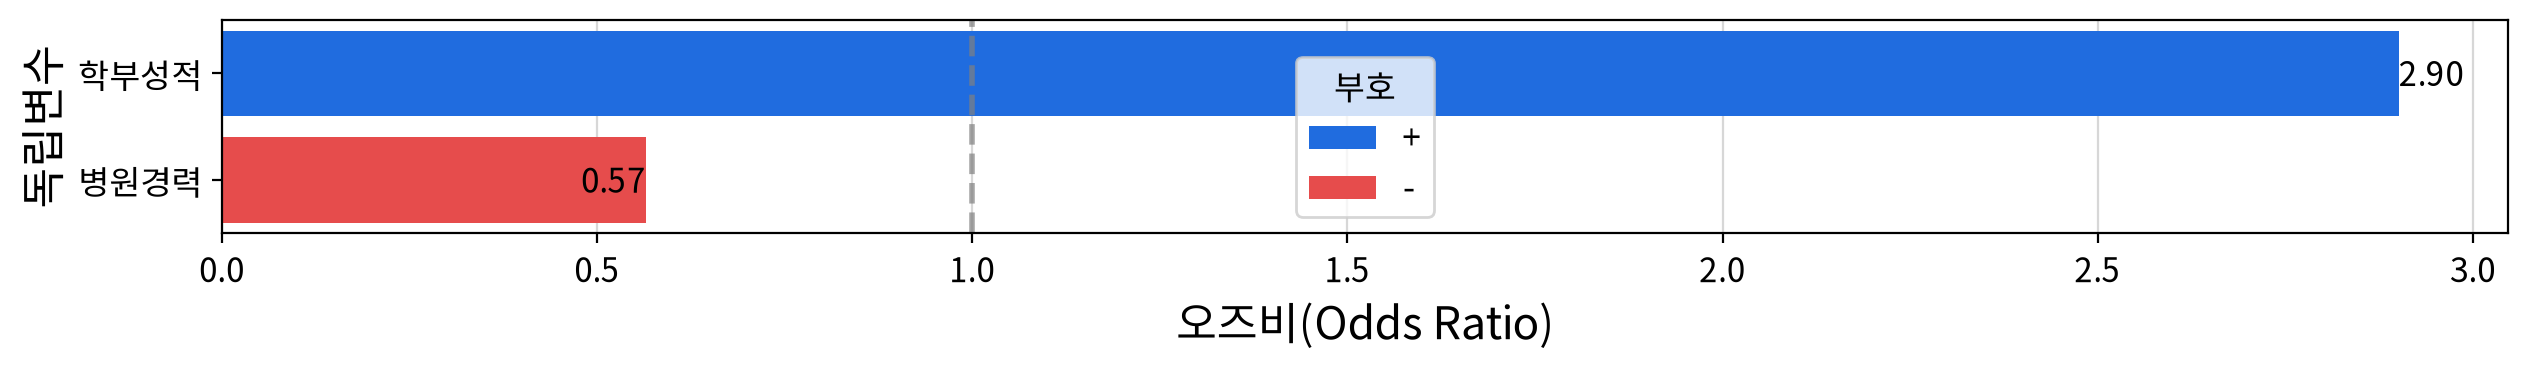

In [10]:
fit = my_logit.auto_logit(df5, y='합격여부', backward=True)

#### 새로운 지원자의 합격 확률 예측

In [11]:
new_data = DataFrame({
    '학부성적': [3.8, 3.8, 3.0, 3.0],
    '병원경력': [1, 4, 1, 4],
})

my_logit.predict(fit, new_data)

,proba,pred
0,0.629,1
1,0.234,0
2,0.419,0
3,0.115,0


### 문제 풀이

#### 1. 원서 자료를 그대로 넣으면 종속변수가 두 값이 아니라는 이유로 분석이 성립하지 않습니다. 결과가 확정되지 않은 지원자를 걷어내고 나면 분석에 쓰이는 관측치는 몇 개가 되나요?

- **정답**: `377`
- **복습 개념**: 이항 로지스틱 회귀의 전제입니다. 종속변수는 0과 1, 두 값만 가져야 합니다. 범주가 셋 이상이면 이 모형에 그대로 넣을 수 없습니다.
- **풀이 접근**: 범주형 변수의 값 분포를 확인해 종속변수의 범주가 몇 종인지 봅니다. 합격도 불합격도 아닌 범주가 있다면 그 행을 제거하고 남은 행 수를 셉니다.
- **근거(계산 결과)**: 합격여부는 불합격 250 / 합격 127 / **보류 23** 으로 3종입니다. 결측치 0건, 중복 0건이므로 줄어드는 것은 보류 23건(5.75%)뿐이고, 400 − 23 = **377행**이 됩니다. 위 코드의 출력에서 `분석 대상 관측치 개수: 377` 로 확인되며, 뒤에 나오는 모형 적합도의 `n = 377` 로 이어집니다.
- **자주 하는 실수**: 보류를 불합격 쪽에 합쳐 400행 그대로 쓰기 쉽습니다. 보류는 "떨어졌다"가 아니라 "아직 정해지지 않았다"이므로 어느 쪽에 붙여도 결과가 왜곡됩니다. 비중이 5.75%로 낮기 때문에 제거가 안전한 경우입니다.

#### 2. 네 개의 원서 항목을 모두 넣은 기준선 모형에서, 다른 항목을 함께 고려하면 합격 여부를 가장 설명하지 못하는 것으로 나타나 가장 먼저 소거되는 항목은 무엇인가요?

- **정답**: `성별`
- **복습 개념**: 후진소거법입니다. 유의확률이 가장 큰(= 가장 유의하지 않은) 변수를 **하나만** 제거하고 모형을 다시 적합하는 과정을 반복합니다.
- **풀이 접근**: 네 항목을 모두 넣어 모형을 적합한 뒤, 결과표의 유의확률 열에서 가장 큰 값을 가진 변수를 찾습니다.
- **근거(계산 결과)**: 기준선 4변수 모형의 유의확률은 병원경력 0.000 < 학부성적 0.011 < 필기점수 0.060 < **성별 0.477** 입니다. 성별이 압도적으로 커서 1순위로 제거되며, 소거 로그에도 `유의하지 않은 독립변수 제거 → 성별 (p = 0.4769)` 로 찍힙니다.
- **실무 포인트**: "유의하지 않다 = 중요하지 않다"가 아닙니다. 학부성적·병원경력을 이미 고려한 상태에서 성별이 **추가로** 설명하는 몫이 없다는 뜻입니다. 남녀 합격률 자체가 같다는 주장과는 다른 이야기입니다.

#### 3. 필기시험 점수는 당연히 합격을 가를 것 같지만 최종 모형에서는 빠집니다. 필기점수가 소거되는 시점의 유의확률은 얼마인가요? (소수 셋째 자리)

- **정답**: `0.066`
- **복습 개념**: 변수를 하나 빼면 남은 변수의 계수·표준오차·유의확률이 함께 달라집니다. 그래서 한 번에 하나씩만 제거하고 매번 다시 적합해야 합니다.
- **풀이 접근**: 첫 변수를 제거한 뒤 다시 적합한 모형에서 필기점수의 유의확률을 읽습니다. 기준선 모형의 값이 아니라 **제거되는 그 시점의 값**입니다.
- **근거(계산 결과)**: 기준선에서는 0.060으로 0.05를 아깝게 넘겼는데, 성별을 빼고 다시 적합하니 **0.066** 으로 더 커져 두 번째 소거 대상이 됩니다. 소거 로그의 `유의하지 않은 독립변수 제거 → 필기점수 (p = 0.0657)` 이 그 값입니다.
- **헷갈리기 쉬운 점**: 기준선의 0.060과 소거 시점의 0.066을 혼동하기 쉽습니다. 두 값이 다르다는 사실 자체가 "유의하지 않은 변수를 한꺼번에 지우면 안 되는 이유"입니다. 필기점수와 학부성적은 학업 역량이라는 같은 뿌리를 공유해 서로 설명력을 나눠 갖습니다. 유의수준을 0.10으로 잡았다면 남았을 경계선 변수라는 점도 함께 기억하세요.

#### 4. 소거가 끝난 최종 모형이 합격 여부를 얼마나 설명하는지를 나타내는 유사결정계수는 얼마인가요? (소수 셋째 자리)

- **정답**: `0.073`
- **복습 개념**: Pseudo R² 입니다. 로지스틱 회귀에는 선형회귀의 R²에 해당하는 값이 없어서 로그우도를 기준으로 계산한 대용값을 씁니다.
- **풀이 접근**: 최종 모형의 적합도 보고에서 Pseudo R² 를 읽습니다. 모형 전체의 유의성(LLR 검정)과는 별개의 지표입니다.
- **근거(계산 결과)**: 최종 모형은 n = 377, LLR χ²(2) = 35.164, p < 0.001, **Pseudo R² = 0.073** 입니다. 유의확률이 0.001 미만이므로 모형 자체는 통계적으로 유의하지만, 설명력은 낮습니다.
- **함께 생각해 볼 점**: Pseudo R² 는 선형회귀의 R² 처럼 '분산의 7.3%를 설명한다'로 읽지 않습니다. 통상 0.2~0.4 구간이면 매우 우수한 적합으로 봅니다. 0.073은 원서의 네 항목만으로는 합격을 거의 예측하지 못한다는 뜻이며, 면접·자기소개서·추천서처럼 이 데이터에 없는 요소가 크게 작용하고 있음을 시사합니다.

#### 5. 입학처장이 "학점 1점 차이가 실제로 얼마나 크냐"고 묻습니다. 최종 모형에서 학부성적이 1점 오를 때 합격 오즈는 몇 배가 되나요? (소수 셋째 자리)

- **정답**: `2.902`
- **복습 개념**: 오즈비(OR)입니다. 로지스틱 회귀의 계수 B는 로그 오즈의 변화량이라 그대로 읽지 않고, 지수를 취해 exp(B) = 오즈의 배수로 해석합니다.
- **풀이 접근**: 최종 모형 결과표의 오즈비 열에서 학부성적 행을 읽습니다. 신뢰구간이 1을 포함하는지도 함께 확인합니다.
- **근거(계산 결과)**: 학부성적의 B = 1.065 이므로 OR = exp(1.065) = **2.902** 입니다. 95% 신뢰구간이 [1.587, 5.307] 로 1을 포함하지 않아 유의합니다(p = 0.001).
- **자주 하는 실수**: 2.902를 "합격 **확률**이 2.9배"로 읽으면 틀립니다. 확률이 아니라 **오즈**(합격 확률 ÷ 불합격 확률)의 배수입니다. 확률 0.3이 오즈 0.43, 확률 0.6이 오즈 1.5인 것처럼 둘은 서로 다른 눈금입니다.

#### 6. 입학처장에게 "이것부터 보라"고 단 하나만 짚어 주려 합니다. 값의 범위가 제각각인 항목들을 같은 잣대로 맞춰 비교했을 때, 합격 여부에 가장 큰 영향을 주는 항목은 무엇인가요?

- **정답**: `병원경력`
- **복습 개념**: 표준화 계수(βstd)입니다. 값의 범위가 다른 변수는 오즈비의 크기로 영향력을 비교할 수 없고, 표준편차 1만큼의 변화로 눈금을 맞춘 βstd 의 **절댓값**으로 비교해야 합니다.
- **풀이 접근**: 최종 모형 결과표의 βstd 열에서 절댓값이 가장 큰 변수를 찾습니다. 부호는 방향일 뿐 크기와는 무관합니다.
- **근거(계산 결과)**: βstd 는 병원경력 **−0.536**, 학부성적 0.411 입니다. 절댓값이 큰 **병원경력**이 1위입니다. 오즈비만 보면 학부성적 2.902 대 병원경력 0.565 로 학부성적이 압도적으로 보이지만, 학부성적은 표준편차가 0.39점이고 병원경력은 0.94년이라 애초에 같은 잣대가 아닙니다.
- **자주 하는 실수**: 오즈비가 크니까 학부성적이라고 답하기 쉽습니다. 오즈비를 직접 비교할 수 있는 것은 변수들의 값의 범위가 같을 때뿐입니다. 그리고 병원경력의 오즈비 0.565 는 1보다 **작으므로**, 경력이 1년 길어질 때 합격 오즈가 약 43.5% 줄어든다는 뜻입니다.

#### 7. "학부성적 3.8, 병원경력 1년"인 지원자가 합격 가능성을 문의해 왔습니다. 최종 모형으로 계산한 이 지원자의 합격 확률은 얼마인가요? (소수 셋째 자리)

- **정답**: `0.629`
- **복습 개념**: 적합된 로지스틱 모형은 새 관측치가 사건(=합격)에 해당할 확률을 계산해 줍니다. 임계값(기본 0.5)을 넘으면 1로 분류합니다.
- **풀이 접근**: 최종 모형에 남아 있는 독립변수만, 같은 순서로 담은 새 데이터를 만들어 예측 확률을 계산합니다. 모형에서 빠진 성별·필기점수는 넣지 않습니다.
- **근거(계산 결과)**: 예측 확률은 **0.629** 로 임계값 0.5를 넘어 합격(1)으로 분류됩니다. 비교하면 같은 학점이라도 병원경력이 4년이면 0.234로 떨어져 불합격(0)이 되고, 학점이 3.0으로 낮아지면 경력 1년이어도 0.419에 그칩니다.
- **결론**: 경력 3년 차이가 만든 확률 하락 폭(0.629 → 0.234)이 학점 0.8점 차이가 만든 폭(0.629 → 0.419)보다 큽니다. 6번에서 표준화 계수로 얻은 결론(병원경력 > 학부성적)과 정확히 같은 이야기입니다. 입학처장에게 보고할 답은 **병원경력**이지만, Pseudo R² 가 0.073에 불과하므로 "이것만 보면 된다"가 아니라 "지금 가진 원서 자료 안에서는 병원경력이 가장 강하게 연동되어 있다"로 수위를 조절해 보고하세요. 또 경력이 길수록 불리하다는 방향은 상식과 어긋나므로, 이 관계가 정말 직선인지는 다음 단원의 로짓 선형성 검정에서 확인해야 합니다.